# Assignment 2 2AMM10 2023-2024

## Group: [Fill in your group name]
### Member 1: [Fill in your name]
### Member 2: [Fill in your name]
### Member 3: [Fill in your name]

We need to install some specific libraries. The cell below installs torch_geometric for torch 2.6.0+cu124. In case the current version of torch is different, check [here](https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html) to see which versions (of both libraries) you should install. You might also need to install an old version of torch from [here](https://pytorch.org/get-started/previous-versions/)

**Note:** Do not install pyg_lib from the optional dependencies

In [2]:
# !pip show torch

In [3]:
# !pip install rdkit
# !pip install torch_geometric
# !pip install torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

In [4]:
import pickle
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')
import matplotlib.pyplot as plt

#added by user
import torch
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
import math
from torch_geometric.loader import DataLoader as GeoLoader
from torch.utils.data import DataLoader as SMILESLoader
from sklearn.metrics import mean_absolute_error, r2_score
import copy
from pytorch_lightning.callbacks import EarlyStopping


c:\Users\kathe\anaconda3\envs\dl-env\Lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
c:\Users\kathe\anaconda3\envs\dl-env\Lib\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
c:\Users\kathe\anaconda3\envs\dl-env\Lib\site-packages\torch_geometric\typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(
c:\Users\kathe\anaconda3\envs\dl-env\Lib\site-packages\torch_geometric\typing.py:124: UserWarning: An issue occurred

In [101]:
with open('pos_data.pkl', 'rb') as f:
    pos_data = pickle.load(f)

with open('type_data.pkl', 'rb') as f:
    type_data = pickle.load(f)

with open('smiles.pkl', 'rb') as f:
    smiles_data = pickle.load(f)

data_split = np.load('data_split.npz')

train_idxes = data_split['train_idx']
test_idxes = data_split['test_idx']

formation_energy = np.load('formation_energy.npz')

fe = formation_energy['y'] # normalized formation energy
mu = formation_energy['mu']
std = formation_energy['sigma']

Length of data
pos_data: 129012, type_data: 129012, smiles: 129012
Idxes
train: 119012, test: 10000, sum: 129012
5


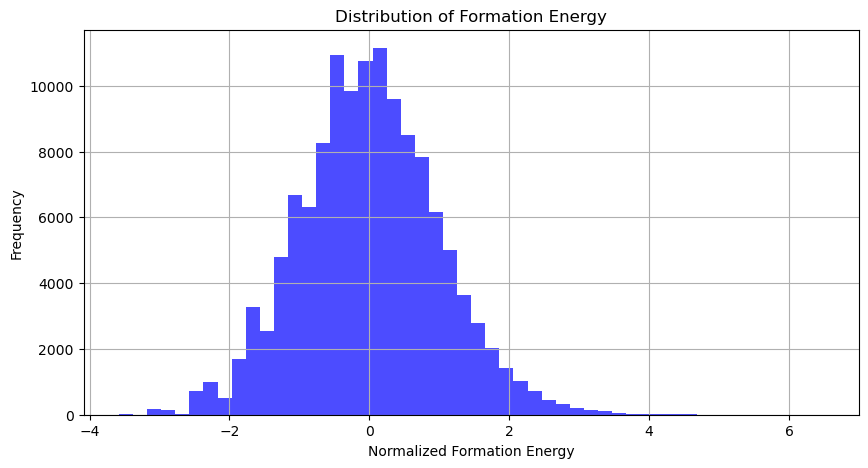

Maximum formation energy: 6.49253511428833
Minimum formation energy: -3.5815374851226807


In [6]:
# shapes of lists
print("Length of data")
print(f"pos_data: {len(pos_data)}, type_data: {len(type_data)}, smiles: {len(smiles_data)}")
print("Idxes")
print(f"train: {len(train_idxes)}, test: {len(test_idxes)}, sum: {len(train_idxes) + len(test_idxes)}")
# print statements
print(pos_data[0].shape[0])

# Visualize fe
plt.figure(figsize=(10, 5))
plt.hist(fe, bins=50, color='blue', alpha=0.7)
plt.title('Distribution of Formation Energy')
plt.xlabel('Normalized Formation Energy')
plt.ylabel('Frequency')
plt.grid()
plt.show()
print(f"Maximum formation energy: {np.max(fe)}")
print(f"Minimum formation energy: {np.min(fe)}")

In [7]:
# Flatten the list of atom types and find unique values
unique_atom_types = np.unique(np.concatenate(type_data))

print(f"Number of unique atom types: {len(unique_atom_types)}")
print(f"Unique atom types: {unique_atom_types}")

# This influence the number of atoms types
atom_type_mapping = {1: 0, 6: 1, 7: 2, 8: 3, 9: 4}
type_data_mapped = [
    torch.tensor([atom_type_mapping[atom.item()] for atom in molecule], dtype=torch.long)
    for molecule in type_data
]

# Update num_atom_types
num_atom_types = len(atom_type_mapping)
print(f"Updated number of atom types: {num_atom_types}")

# We want to create embeddings fo each atom type, since we thus only have five we must adjust the indexing such that the embedding can do that. 

Number of unique atom types: 5
Unique atom types: [1 6 7 8 9]
Updated number of atom types: 5


In [8]:
def at_number_to_atom_name(at_number):
    if at_number == 6:
        return 'C'
    elif at_number == 1:
        return 'H'
    elif at_number == 7:
        return 'N'
    elif at_number == 8:
        return 'O'
    elif at_number == 9:
        return 'F'
    elif at_number == 16:
        return 'S'
    else:
        return 'Unknown'

def inspect_structure(idx):
    smile = smiles_data[idx]
    pos = pos_data[idx]
    typ = type_data[idx]

    header = f"{'Atom':^5}│{'Number':^6}│{'x':^10}│{'y':^10}│{'z':^10}"
    line   = "─────┼──────┼──────────┼──────────┼──────────"
    print(header)
    print(line)

    for atom_num, (x, y, z) in zip(typ, pos):
        atom_sym = at_number_to_atom_name(atom_num)
        print(f"{atom_sym:^5}│{atom_num:^6}│{x:>10.3f}│{y:>10.3f}│{z:>10.3f}")
    print("")
    print("")
    print(f'SMILE: {smile}')
    print("")
    print("")
    print(f'Formation Energy: {fe[idx]*std + mu:.3f}')
    print(f'Formation Energy (normalized): {fe[idx]:.5f}')
    mol = Chem.MolFromSmiles(smile)
    if mol:
        # RDKit prefers 2‑D coordinates for nice depictions
        Chem.AllChem.Compute2DCoords(mol)
        img = Draw.MolToImage(mol, size=(300, 300))

        # Display with matplotlib (works both in notebooks and scripts)
        plt.figure(figsize=(3, 3))
        plt.axis('off')
        plt.imshow(img)
        plt.show()

Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │    -0.013│     1.086│     0.008
  H  │  1   │     0.002│    -0.006│     0.002
  H  │  1   │     1.012│     1.464│     0.000
  H  │  1   │    -0.541│     1.447│    -0.877
  H  │  1   │    -0.524│     1.438│     0.906


SMILE: C


Formation Energy: -17.172
Formation Energy (normalized): 5.72327


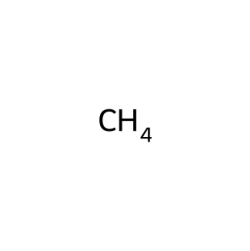

In [9]:
# methane
# Note how methane has a relatively high formation energy (compared to QM9)
# This correlates with lower thermodynamic stability and higher reactivity
# For example, methane readily burns in oxygen (CH₄ + 2O₂ → CO₂ + 2H₂O)
inspect_structure(0)

Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │     0.477│     1.384│    -0.317
  C  │  6   │    -0.062│     0.032│     0.164
  O  │  8   │    -0.086│    -0.888│    -0.947
  C  │  6   │     0.912│    -1.783│    -1.173
  N  │  7   │     0.888│    -2.555│    -2.178
  C  │  6   │     2.052│    -1.846│    -0.181
  C  │  6   │     1.663│    -1.374│     1.190
  C  │  6   │     0.678│    -0.497│     1.369
  C  │  6   │     0.251│     0.027│     2.711
  H  │  1   │     1.533│     1.305│    -0.589
  H  │  1   │    -0.086│     1.722│    -1.191
  H  │  1   │     0.382│     2.140│     0.469
  H  │  1   │    -1.122│     0.151│     0.419
  H  │  1   │     0.057│    -2.366│    -2.742
  H  │  1   │     2.419│    -2.875│    -0.173
  H  │  1   │     2.883│    -1.240│    -0.572
  H  │  1   │     2.221│    -1.761│     2.039
  H  │  1   │     0.867│    -0.389│     3.511
  H  │  1   │     0.325│     1.121│     2.763
  H  │  1   │    -0.797│    -0.225

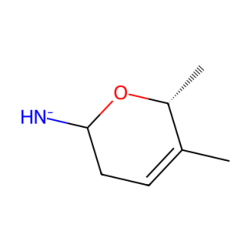

In [10]:
# random structure
inspect_structure(np.random.choice(range(len(smiles_data))))

In [11]:
# Check device settings
if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

print(f'The available device is {device}')

The available device is cuda


## Task 1

GEOMETRICAL REPRESENTATION

In [12]:
# This I have not checked yet. The code seems to work fine. The cutoff in literature is most about A something.
def build_edges_molecule(positions, cutoff):
    """
    Given a single molecule's atom positions (Nx3 tensor or list of N 3D coords),
    returns edge_index suitable for SchNet input.
    """
    if not isinstance(positions, torch.Tensor):
        positions = torch.tensor(positions, dtype=torch.float32)

    num_atoms = positions.size(0) # positions is here the molecule and those the shape of the tensor
    list_from = []
    list_to = []

    for i in range(num_atoms):
        for j in range(num_atoms):
            if i == j:
                continue
            dist = torch.norm(positions[i] - positions[j])
            if dist < cutoff:
                list_from.append(i)
                list_to.append(j)

    edge_index = torch.tensor([list_from, list_to], dtype=torch.long)
    return edge_index

def build_edges_all(pos_data, cutoff):
    """
    Build edge indices for all molecules in pos_data
    """
    edge_indices = []

    for molecule in pos_data: # each molecule in the pos_data can consists of several atoms (max 29 in data)
        edge_index = build_edges_molecule(molecule, cutoff=cutoff)
        edge_indices.append(edge_index)

    return edge_indices # alist of tensors of shape [2, E] where E is the number of edges in each molecule


--- Edge Analysis by Cutoff ---

Analyzing cutoff: 1.0 Total number of edges across all molecules: 100632 Average number of edges per molecule: 0.78 Maximum number of edges in a single molecule: 8

Analyzing cutoff: 1.5 Total number of edges across all molecules: 3715924 Average number of edges per molecule: 28.80 Maximum number of edges in a single molecule: 46

Analyzing cutoff: 2.0 Total number of edges across all molecules: 6122042 Average number of edges per molecule: 47.45 Maximum number of edges in a single molecule: 94

Analyzing cutoff: 2.5 Total number of edges across all molecules: 12977958 Average number of edges per molecule: 100.59 Maximum number of edges in a single molecule: 198

In [13]:
#edge_indices = build_edges_all(pos_data, cutoff=1.5)

# Save
#torch.save(edge_indices, "edges.pt")

# Load
edge_indices = torch.load("edges.pt")

pos_data = [torch.tensor(mol, dtype=torch.float32) for mol in pos_data]
type_data = [torch.tensor(mol, dtype=torch.long) for mol in type_data]

# Goal of this code is to create for all the three aspects of the data a list of tensors
# Think about whether this is correctly used

C:\Users\kathe\AppData\Local\Temp\ipykernel_10040\3638787805.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  edge_indices = torch.load("edges.pt")


In [14]:
class MoleculeDataset(torch.utils.data.Dataset):
    def __init__(self, atom_types_list, positions_list, edge_indices_list, targets):
        self.atom_types_list = atom_types_list
        self.positions_list = positions_list
        self.edge_indices_list = edge_indices_list
        self.targets = targets

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        # Create a torch_geometric.data.Data object for each molecule
        data = Data(
            x=self.atom_types_list[idx],  # Node features (atom types)
            pos=self.positions_list[idx],  # Node positions
            edge_index=self.edge_indices_list[idx],  # Edge indices
            y=self.targets[idx]  # Target value
        )
        return data

In [15]:
# also based upon https://arxiv.org/abs/1706.08566 the original SchNet paper

class RBFExpansion(nn.Module):
    """
    Radial Basis Function Expansion is a way to transform distances
    into a set of features that can be used in neural networks. The idea is that it must become higher dimensional to be more expressive.
    This uses a Gaussian RBF, like in SchNet.
    """
    def __init__(self, num_rbf=300, cutoff=1.5, gamma=10.0):
        super().__init__()
        centers = torch.linspace(0, cutoff, num_rbf) #create RBF centers, creates num_rbf values from 0 to cutoff
        self.register_buffer('centers', centers) #for GPU compatibility
        self.gamma = gamma # larger gamma means sharper peaks in the RBF

    def forward(self, distances):
        return torch.exp(-self.gamma * (distances.unsqueeze(1) - self.centers) ** 2)

class ShiftedSoftplus(nn.Module):
    def forward(self, x):
        return F.softplus(x) - math.log(2)
    
class ReadoutMLP(nn.Module):
    def __init__(self, hidden_dim=256, mid_dim=128):
        super().__init__()
        self.atom_dense1 = nn.Linear(hidden_dim, mid_dim)  # atom-wise layer
        self.activation = ShiftedSoftplus()               
        self.atom_dense2 = nn.Linear(mid_dim, 1)           # atom-wise layer to scalar

    def forward(self, h, batch_idx):
        h = self.atom_dense1(h)
        h = self.activation(h)
        h = self.atom_dense2(h)
        h = h.squeeze(-1)  # ensure h is 1D per atom

        num_graphs = batch_idx.max().item() + 1
        energy = torch.zeros(num_graphs, device=h.device)
        energy = energy.index_add(0, batch_idx, h)  # sum pooling

        return energy

class MLP(nn.Module):
    """
    simple Multi-Layer Perceptron (MLP) with Shifted Softplus activations.
    """
    def __init__(self, in_dim, out_dim, hidden_dim=256):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            ShiftedSoftplus(), 
            nn.Linear(hidden_dim, out_dim),
            ShiftedSoftplus(), 
        )

    def forward(self, x):
        return self.model(x)
    
class InteractionBlock(nn.Module):
    def __init__(self, hidden_dim, num_rbf, cutoff):
        super().__init__()
        self.rbf_layer = RBFExpansion(num_rbf, cutoff)  
        self.filter_net = MLP(num_rbf, hidden_dim) # learns filters
        self.atom_dense = nn.Linear(hidden_dim, hidden_dim)
        self.cutoff = cutoff
        self.post_dense1 = nn.Linear(hidden_dim, hidden_dim)
        self.activation = ShiftedSoftplus()
        self.post_dense2 = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, h, edge_index, positions):
        # This order of source and target is reversed here
        source, target = edge_index # source is j, target is i
        distances = torch.norm(positions[source] - positions[target], dim=1)

        # Compute RBF and filters
        rbf = self.rbf_layer(distances)
        f_ij = self.filter_net(rbf) # these are the filters

        # Cosine cutoff
        cutoff_weight = 0.5 * torch.cos((torch.pi * distances) / (2 * self.cutoff))

        # Message passing from source to target
        h_proj = self.atom_dense(h[source])
        m_ij = f_ij * h_proj * cutoff_weight.unsqueeze(-1)

        agg = torch.zeros_like(h)
        agg.index_add_(0, target, m_ij)

    
        out = self.post_dense1(agg)
        out = self.activation(out)
        out = self.post_dense2(out)
        return h + out

class SchNetLightning(pl.LightningModule):
    def __init__(self, num_atom_types, hidden_dim=256, num_rbf=300, num_blocks=5, lr=1e-4, cutoff=1.5):
        super().__init__()
        self.save_hyperparameters()
        self.embedding = nn.Embedding(num_atom_types, hidden_dim)
        self.interaction_blocks = nn.ModuleList(
            [InteractionBlock(hidden_dim, num_rbf, cutoff) for _ in range(num_blocks)]
        )
        self.readout = ReadoutMLP(hidden_dim)

        #without tensors does not work on gpu
        self.register_buffer('std_tensor', torch.tensor(std))
        self.register_buffer('mu_tensor',  torch.tensor(mu))

        # buffers per epoch
        self._train_norm_buf   = []
        self._train_denorm_buf = []
        self._val_norm_buf     = []
        self._val_denorm_buf   = []

        # for plottingthe curve
        self.train_losses_norm   = []
        self.train_losses_denorm = []
        self.val_losses_norm     = []
        self.val_losses_denorm   = []

    def forward(self, atom_types, positions, edge_index, batch_idx):
        h = self.embedding(atom_types)
        for block in self.interaction_blocks:
            h = block(h, edge_index, positions)
        return self.readout(h, batch_idx)

    def training_step(self, batch, batch_idx):
        y = batch.y
        preds = self(batch.x, batch.pos, batch.edge_index, batch.batch).squeeze()
        # normalized loss
        loss_norm = F.mse_loss(preds, y)
        # denormalized loss
        denorm_preds   = preds * self.std_tensor + self.mu_tensor
        denorm_targets = y * self.std_tensor + self.mu_tensor
        loss_denorm = F.mse_loss(denorm_preds, denorm_targets)
        # buffer for epoch
        self._train_norm_buf.append(loss_norm.detach())
        self._train_denorm_buf.append(loss_denorm.detach())
        # normalized loss id used for optimizer step
        return loss_norm

    def on_train_epoch_end(self):
        # collect buffered losses
        avg_norm = torch.stack(self._train_norm_buf).mean().item()
        avg_denorm = torch.stack(self._train_denorm_buf).mean().item()
        # record history
        self.train_losses_norm.append(avg_norm)
        self.train_losses_denorm.append(avg_denorm)
        # clear buffers for epoch
        self._train_norm_buf.clear()
        self._train_denorm_buf.clear()
        # log epoch metrics
        self.log('train_loss_norm', avg_norm, prog_bar=True)
        self.log('train_loss_denorm', avg_denorm, prog_bar=True)

    def validation_step(self, batch, batch_idx):
        y = batch.y
        preds = self(batch.x, batch.pos, batch.edge_index, batch.batch).squeeze()
        loss_norm = F.mse_loss(preds, y)
        denorm_preds = preds * self.std_tensor + self.mu_tensor
        denorm_targets = y * self.std_tensor + self.mu_tensor
        loss_denorm = F.mse_loss(denorm_preds, denorm_targets)
        # buffer for epoch
        self._val_norm_buf.append(loss_norm.detach())
        self._val_denorm_buf.append(loss_denorm.detach())


    def on_validation_epoch_end(self):
        # aggregate buffered losses
        avg_norm = torch.stack(self._val_norm_buf).mean().item()
        avg_denorm = torch.stack(self._val_denorm_buf).mean().item()
        # record history
        self.val_losses_norm.append(avg_norm)
        self.val_losses_denorm.append(avg_denorm)
        # clear buffers
        self._val_norm_buf.clear()
        self._val_denorm_buf.clear()
        # log epoch metrics
        self.log('val_loss_norm', avg_norm, prog_bar=True)
        self.log('val_loss_denorm', avg_denorm, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr, weight_decay=1e-6)
       


In [16]:
batch_size = 128
train_idx, val_idx = train_test_split(train_idxes, test_size=0.2, random_state=0)

train_dataset = MoleculeDataset(
    [type_data_mapped[i] for i in train_idx],
    [pos_data[i] for i in train_idx],
    [edge_indices[i] for i in train_idx],
    torch.tensor([fe[i] for i in train_idx], dtype=torch.float32)
)

val_dataset = MoleculeDataset(
    [type_data_mapped[i] for i in val_idx],
    [pos_data[i] for i in val_idx],
    [edge_indices[i] for i in val_idx],
    torch.tensor([fe[i] for i in val_idx], dtype=torch.float32)
)

test_dataset = MoleculeDataset(
    [type_data_mapped[i] for i in test_idxes],
    [pos_data[i] for i in test_idxes],
    [edge_indices[i] for i in test_idxes],
    torch.tensor([fe[i] for i in test_idxes], dtype=torch.float32)
)

train_loader = GeoLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = GeoLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = GeoLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [17]:
# List of hyperparameters

hidden_dim = 256
num_rbf = 300 # in origal it was rbf300
num_blocks = 5
cutoff = 1.5 # it does not make sen to change the cutoff as long as i dont rerun the edge code
lr = 1e-4
max_epochs = 50
gamma = 10.0

In [18]:
# std_tensor = torch.tensor(std, device=device, dtype=torch.float32)
# mu_tensor = torch.tensor(mu, device=device, dtype=torch.float32)

# # Code to train the model
# def train_model(model, train_loader, val_loader, num_epochs=10, learning_rate=1e-3, device='cpu'):
#     model.to(device)
#     criterion = nn.MSELoss()
#     optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
#     train_losses = []
#     val_losses = []
#     train_denorm_losses = []  
#     val_denorm_losses = []    

#     for epoch in range(num_epochs):
#         # Training step
#         model.train()
#         total_loss = 0.0
#         total_denorm_loss = 0.0

#         for batch in train_loader:
#             batch = batch.to(device)

#             optimizer.zero_grad()
#             preds = model(batch.x, batch.pos, batch.edge_index, batch.batch)
#             loss = criterion(preds.squeeze(), batch.y)

#             # Compute denormalized loss
#             denorm_preds = preds * std_tensor + mu_tensor
#             denorm_targets = batch.y * std_tensor + mu_tensor
#             denorm_loss = criterion(denorm_preds.squeeze(), denorm_targets)

#             # Backpropagation
#             loss.backward()
#             optimizer.step()

#             total_loss += loss.item()
#             total_denorm_loss += denorm_loss.item()

#         avg_loss = total_loss / len(train_loader)
#         avg_denorm_loss = total_denorm_loss / len(train_loader)
#         train_losses.append(avg_loss)
#         train_denorm_losses.append(avg_denorm_loss)
#         print(f"Epoch {epoch + 1}/{num_epochs}, Training Loss (normalized): {avg_loss:.4f}, Training Loss (denormalized): {avg_denorm_loss:.4f}")

#         # Validation step
#         model.eval()
#         val_loss = 0.0
#         val_denorm_loss = 0.0
#         with torch.no_grad():
#             for batch in val_loader:
#                 batch = batch.to(device)
#                 preds = model(batch.x, batch.pos, batch.edge_index, batch.batch)
#                 loss = criterion(preds.squeeze(), batch.y)

#                 # Compute denormalized loss
#                 denorm_preds = preds * std_tensor + mu_tensor
#                 denorm_targets = batch.y * std_tensor + mu_tensor
#                 denorm_loss = criterion(denorm_preds.squeeze(), denorm_targets)

#                 val_loss += loss.item()
#                 val_denorm_loss += denorm_loss.item()

#         avg_val_loss = val_loss / len(val_loader)
#         avg_val_denorm_loss = val_denorm_loss / len(val_loader)
#         val_losses.append(avg_val_loss)
#         val_denorm_losses.append(avg_val_denorm_loss)
#         print(f"Validation Loss (normalized): {avg_val_loss:.4f}, Validation Loss (denormalized): {avg_val_denorm_loss:.4f}")

#     # Plot training and validation loss curves
#     plt.figure(figsize=(10, 6))
#     plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss (normalized)', marker='o')
#     plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss (normalized)', marker='o')
#     plt.plot(range(1, num_epochs + 1), train_denorm_losses, label='Training Loss (denormalized)', marker='x')
#     plt.plot(range(1, num_epochs + 1), val_denorm_losses, label='Validation Loss (denormalized)', marker='x')
#     plt.xlabel('Epochs')
#     plt.ylabel('Loss')
#     plt.title('Training and Validation Loss Curves')
#     plt.legend()
#     plt.grid()
#     plt.show()

#     # Save losses
#     losses = {
#         "train_losses": train_losses,
#         "val_losses": val_losses
#     }
#     with open("losses.pkl", "wb") as f:
#         pickle.dump(losses, f)
#     print("Training and validation losses saved to 'losses.pkl'")

In [19]:
model = SchNetLightning(num_atom_types=num_atom_types, hidden_dim=hidden_dim, num_blocks=num_blocks, lr=lr)
# train_model(model, train_loader, val_loader, num_epochs=max_epochs, learning_rate=lr, device=device)

trainer = pl.Trainer(
    max_epochs=30,
    accelerator='auto',
    callbacks=[EarlyStopping(monitor='val_loss_norm', patience=5)],
    enable_progress_bar=True
)

trainer.fit(model, train_loader, val_loader)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\kathe\anaconda3\envs\dl-env\Lib\site-packages\pytorch_lightning\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
You are using a CUDA device ('NVIDIA RTX A500 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which wi

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\kathe\anaconda3\envs\dl-env\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\kathe\anaconda3\envs\dl-env\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

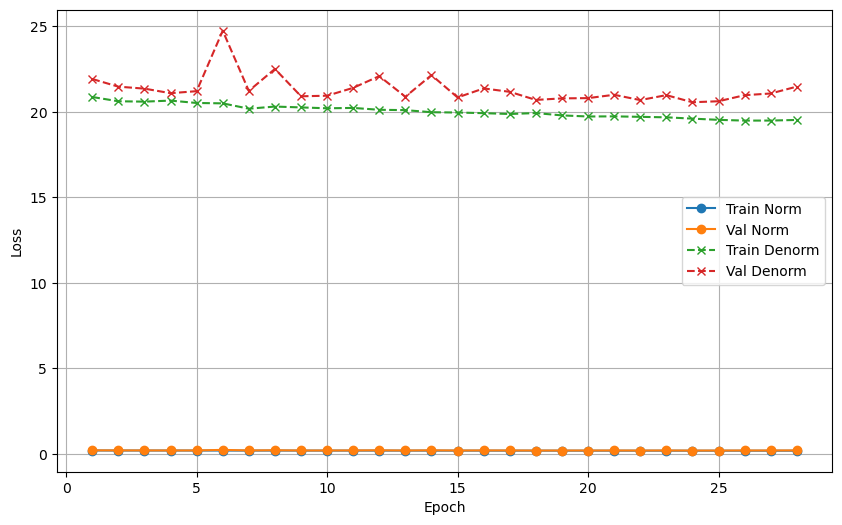

In [25]:
train_norm = model.train_losses_norm
val_norm = model.val_losses_norm[:len(train_norm)] 
train_denorm = model.train_losses_denorm
val_denorm   = model.val_losses_denorm[:len(train_denorm)]
epochs = list(range(1, len(train_norm)))

plt.figure(figsize=(10,6))
plt.plot(epochs, train_norm[1:], 'o-', label='Train Norm')
plt.plot(epochs, val_norm[1:], 'o-', label='Val Norm')
plt.plot(epochs, train_denorm[1:], 'x--',label='Train Denorm')
plt.plot(epochs, val_denorm[1:], 'x--',label='Val Denorm')
plt.legend()
plt.grid()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [26]:
# Set model to evaluation mode
std = torch.tensor(std, device=device)
mu  = torch.tensor(mu, device=device)

model = model.to(device)
model.eval()

test_losses = []
test_mae = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        preds = model(batch.x, batch.pos, batch.edge_index, batch.batch)

        # Denormalize predictions and targets as we want to evaluate the test on that
        original_preds = preds * std + mu
        original_targets = batch.y * std + mu

        mse_loss = F.mse_loss(original_preds, original_targets)
        mae_loss = F.l1_loss(original_preds, original_targets)
        test_losses.append(mse_loss.item())
        test_mae.append(mae_loss.item())

mean_test_loss = sum(test_losses) / len(test_losses)
mean_test_mae = sum(test_mae) / len(test_mae)

print(f"Test MSE loss (original scale): {mean_test_loss:.4f}")
print(f"Test MAE loss (original scale): {mean_test_mae:.4f}")

Test MSE loss (original scale): 20.3809
Test MAE loss (original scale): 2.5450


In [27]:
# Save the model
torch.save(model.state_dict(), "schnet_model.pth")
print("Model saved successfully!")

Model saved successfully!


In [28]:
with open("losses.pkl", "rb") as f:
    losses = pickle.load(f)

train_losses = (torch.tensor(losses["train_losses"], dtype=torch.float32, device=device)* (std**2))
val_losses = (torch.tensor(losses["val_losses"], dtype=torch.float32, device=device))

print("Loaded training losses:", train_losses.tolist())
print("Loaded validation losses:", val_losses.tolist())

Loaded training losses: [23.94417381286621, 21.075782775878906, 20.773303985595703, 20.733346939086914, 20.800386428833008, 20.64005470275879, 20.572330474853516, 20.354127883911133, 20.43563461303711, 20.33772850036621, 20.242149353027344, 20.143762588500977, 20.275043487548828, 20.37615203857422, 20.076663970947266, 20.13054656982422, 19.982200622558594, 19.94321060180664, 19.94666290283203, 19.821353912353516, 19.808677673339844, 19.750125885009766, 19.71874237060547, 19.671140670776367, 19.65132713317871, 19.579036712646484, 19.593975067138672, 19.583885192871094, 19.534820556640625, 19.459796905517578, 19.42694091796875, 19.372522354125977, 19.370868682861328, 19.385223388671875, 19.337406158447266, 19.33614730834961, 19.27178382873535, 19.260583877563477, 19.21029281616211, 19.177566528320312, 19.184513092041016, 19.145336151123047, 19.118244171142578, 19.106853485107422, 19.074337005615234, 19.05667495727539, 19.029373168945312, 18.996135711669922, 18.959697723388672, 18.9267101

SMILES REPRESENTATION

In [29]:
import re
SMILES_REGEX = r"(\[[^\[\]]{1,6}\]|Br|Cl|Si|[BCNOFPSIbcnops*=#%@+\-\[\]\\/0-9])"
# Tokenize the SMILES strings
# https://jcheminf.biomedcentral.com/articles/10.1186/s13321-023-00725-9
# Unclear to me whether we want to encode to values, but seems logical
class SMILESAISTokenizer:
    """
    For each atom in the molecule, it build a token in the format:
    symbol:charge:chirality:hydrogens:ring_status:[neighbors]
    """
    
    def __init__(self):
        self.vocab = set()
        self.special_tokens = ['<PAD>', '<SOS>', '<EOS>', '<UNK>']
        self.token_to_idx = {}
        self.idx_to_token = {}

    def build_vocabulary(self, smiles_list):
        """
        Builds a vocabulary from a list of SMILES strings, it collect unique tokens
        returns a full vocabulary list
        """
        tokens = set()

        for smi in smiles_list:
            tokens.update(self.tokenize(smi))

        tokens = sorted(list(tokens))
        full_vocab = self.special_tokens + tokens
        self.vocab = full_vocab
        self.token_to_idx = {tok: i for i, tok in enumerate(full_vocab)}
        self.idx_to_token = {i: tok for tok, i in self.token_to_idx.items()}

        return full_vocab

    def tokenize(self, smiles):
        return re.findall(SMILES_REGEX, smiles)

    def encode(self, smiles, max_length=None):
        """
        converts a SMILES string into a list of token indices
        """
        tokens = self.tokenize(smiles)
        # Add <SOS> and <EOS> tokens to learn start and end of sequence
        tokens = ['<SOS>'] + tokens + ['<EOS>']
        #<UNK> if it encounters a token that it has not seen before
        encoded = [self.token_to_idx.get(tok, self.token_to_idx['<UNK>']) for tok in tokens]

        if max_length:
            encoded = encoded[:max_length]
            encoded += [self.token_to_idx['<PAD>']] * (max_length - len(encoded))
        return encoded



In [30]:
# Randomized augmentation: https://pubs.rsc.org/en/content/articlelanding/2022/dd/d2dd00058j
class SMILESDataset(Dataset):
    """
    Takes a list of SMILES strings and formation energies and tokenizes the SMILES strings.
    """
    def __init__(self, tokenizer, smiles_list, formation_energy, max_length=None):
        self.tokenizer = tokenizer
        self.smiles = smiles_list
        self.max_length = max_length
        self.formation_energy = formation_energy

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        smiles = self.smiles[idx]
        encoded = self.tokenizer.encode(smiles, max_length=self.max_length)
        target = self.formation_energy[idx]
        return torch.tensor(encoded, dtype=torch.long), torch.tensor(target, dtype=torch.float32)



In [31]:
# Create tokenzier and dataset
# Split data into train and validation 80/20, already having a test dataset
train_data = [smiles_data[i] for i in train_idxes[:-int(0.2 * len(train_idxes))]] # select first 80% of train_idxes; no overlap measured
val_data = [smiles_data[i] for i in train_idxes[-int(0.2 * len(train_idxes)):]] # select last 20% of train_idxes; no overlap measured
test_data = [smiles_data[i] for i in test_idxes]

tokenizer = SMILESAISTokenizer()
tokenizer.build_vocabulary(train_data)
max_length = 100 # the  maximum length of SMILES strings is 62, tokenization might change that

train_targets = fe[train_idxes[:-int(0.2 * len(train_idxes))]]
val_targets = fe[train_idxes[-int(0.2 * len(train_idxes)):]]
test_targets = fe[test_idxes]

train_dataset = SMILESDataset(tokenizer, train_data, train_targets, max_length=max_length)
val_dataset = SMILESDataset(tokenizer, val_data, val_targets, max_length=max_length)
test_dataset = SMILESDataset(tokenizer, test_data, test_targets, max_length=max_length)

# batch size could potentially be increased with lots of data
train_loader = SMILESLoader(train_dataset, batch_size=32, num_workers=0, shuffle=True)
val_loader = SMILESLoader(val_dataset, batch_size=32, num_workers=0, shuffle=False)
test_loader = SMILESLoader(test_dataset, batch_size=32, num_workers=0, shuffle=False)

In [32]:
# Transformer block
# https://pubs.rsc.org/en/content/articlelanding/2022/dd/d2dd00058j
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.layer_norm1 = nn.LayerNorm(embed_dim)
        self.layer_norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.GELU(),
            nn.Linear(ff_dim, embed_dim)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # Multi-head attention with residual connection
        attn_output, _ = self.attention(x, x, x)
        x = self.layer_norm1(x + self.dropout(attn_output))

        # Feed-forward network with residual connection
        mlp_output = self.mlp(x)
        x = self.layer_norm2(x + self.dropout(mlp_output))

        return x

In [33]:
class PositionalEncoding(nn.Module):
    """implements positional encoding for input sequences"""
    def __init__(self, embed_dim, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-torch.log(torch.tensor(10000.0)) / embed_dim))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [34]:
class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_layers, max_len, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.positional_encoding = PositionalEncoding(embed_dim, max_len)
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_dim, dropout) for _ in range(num_layers)
        ])
        self.layer_norm = nn.LayerNorm(embed_dim)
        self.regression_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.GELU(),
            nn.Linear(embed_dim // 2, 1)  # Output a single value
        )

    def forward(self, x):
        # Input embedding + positional encoding
        x = self.embedding(x)
        x = self.positional_encoding(x)

        # Pass through Transformer blocks
        for block in self.transformer_blocks:
            x = block(x)

        # Apply LayerNorm and regression head
        x = self.layer_norm(x)
        x = x.mean(dim=1)  # Global pooling (mean over sequence length)
        x = self.regression_head(x)

        return x
    
class SMILESDecoderTransformer(pl.LightningModule):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_layers, max_len, lr=1e-4, dropout=0.1):
        super().__init__()
        self.save_hyperparameters()

        #original model
        self.model = TransformerDecoder(
            vocab_size=vocab_size,
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=ff_dim,
            num_layers=num_layers,
            max_len=max_len,
            dropout=dropout,
        )
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        return self.model(x).squeeze(-1)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y)
        self.log("train_loss", loss, on_epoch=True, prog_bar=False)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.loss_fn(y_hat, y)
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

In [35]:
#callback to plot the curve since we use lightning now
class LossCurvePlotter(pl.Callback):
    def __init__(self):
        super().__init__()
        self.train_losses = []
        self.val_losses = []

    def on_train_epoch_end(self, trainer, pl_module, outputs=None):
        loss = trainer.callback_metrics.get("train_loss")
        if loss is not None:
            self.train_losses.append(loss.cpu().item())

    def on_validation_epoch_end(self, trainer, pl_module, outputs=None):
        loss = trainer.callback_metrics.get("val_loss")
        if loss is not None:
            self.val_losses.append(loss.cpu().item())

    def on_train_end(self, trainer, pl_module):
        # only plot overlapping epochs
        num_epochs = min(len(self.train_losses), len(self.val_losses))
        epochs = range(1, num_epochs + 1)
        plt.figure(figsize=(10, 6))
        plt.plot(epochs, self.train_losses[:num_epochs], label="Training Loss", marker="o")
        plt.plot(epochs, self.val_losses[:num_epochs], label="Validation Loss", marker="o")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training vs. Validation Loss")
        plt.grid()
        plt.legend()
        plt.show()

In [36]:
# Inital guess for parameters
vocab_size = len(tokenizer.vocab)  # Vocabulary size from tokenizer
embed_dim = 128  # Embedding dimension
num_heads = 4  # Number of attention heads; research further the relation between embed dim and heads
ff_dim = 512 # Feed-forward network dimension; typically 4 times embedding so 1024
num_layers = 6  # Number of Transformer layers
max_len = 100  # Maximum sequence length; should be checked based on tokenization

# model = TransformerDecoder(vocab_size, embed_dim, num_heads, ff_dim, num_layers, max_len)
model = SMILESDecoderTransformer(
    vocab_size=vocab_size,
    embed_dim=embed_dim,
    num_heads=num_heads,
    ff_dim=ff_dim,
    num_layers=num_layers,
    max_len=max_len,
    lr=lr,
)
# Example input (batch of tokenized SMILES)
input_tokens = torch.randint(0, vocab_size, (32, max_len))  # Batch of 32 sequences
output = model(input_tokens)  # Output shape: (32, 1)
print(output.shape)  # Should be [32, 1]

torch.Size([32])


In [ ]:
# # Code to train the model - i have replaced with lightning
# def train_model(model, train_loader, val_loader, num_epochs=10, learning_rate=1e-3):
#     model.to(device)
#     criterion = nn.MSELoss()
#     optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
#     train_losses = []
#     val_losses = []

#     for epoch in range(num_epochs):
#         model.train()
#         total_loss = 0.0

#         for i, (batch, targets) in enumerate(train_loader):
#             batch = batch.to(device)
#             targets = targets.to(device)
#             optimizer.zero_grad()
#             outputs = model(batch)
#             loss = criterion(outputs.squeeze(), targets)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()

#         avg_loss = total_loss / len(train_loader)
#         train_losses.append(avg_loss)
#         print(f"Epoch {epoch + 1}/{num_epochs}, Training Loss: {avg_loss:.4f}")

#         # Validation step
#         model.eval()
#         val_loss = 0.0
#         with torch.no_grad():
#             for i, (batch, targets) in enumerate(val_loader):
#                 batch = batch.to(device)
#                 targets = targets.to(device)
#                 outputs = model(batch)
#                 loss = criterion(outputs.squeeze(), targets)
#                 val_loss += loss.item()

#         avg_val_loss = val_loss / len(val_loader)
#         val_losses.append(avg_val_loss)
#         print(f"Validation Loss: {avg_val_loss:.4f}")

#     plt.figure(figsize=(10, 6))
#     plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss', marker='o')
#     plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss', marker='o')
#     plt.xlabel('Epochs')
#     plt.ylabel('Loss')
#     plt.title('Training and Validation Loss Curves')
#     plt.legend()
#     plt.grid()
#     plt.show()

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type               | Params | Mode 
-------------------------------------------------------
0 | model   | TransformerDecoder | 1.2 M  | train
1 | loss_fn | MSELoss            | 0      | train
-------------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.814     Total estimated model params size (MB)
70        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\kathe\anaconda3\envs\dl-env\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
c:\Users\kathe\anaconda3\envs\dl-env\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

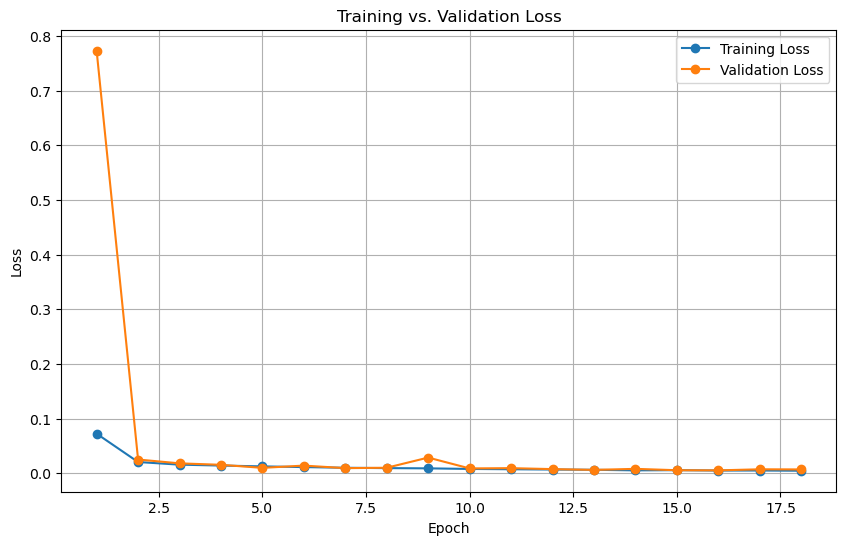

In [37]:
# Train the model;learning rate potentially lower is better 
# train_model(model, train_loader, val_loader, num_epochs=10, learning_rate=1e-4)

loss_plotter = LossCurvePlotter()
early_stopping = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=3, mode="min")
trainer = pl.Trainer(
    max_epochs=30,
    accelerator="auto",
    devices=1,
    callbacks=[loss_plotter, early_stopping]
)   

trainer.fit(model, train_loader, val_loader)
# Save the model
torch.save(model.state_dict(), 'transformer_decoder.pth')


In [38]:
import torch.nn.functional as F

model.to(device)
model.eval()
test_losses = []
test_mae = []

# Ensure std and mu are tensors and on the correct device
if not isinstance(std, torch.Tensor):
    std = torch.tensor(std)
if not isinstance(mu, torch.Tensor):
    mu = torch.tensor(mu)
std = std.to(device)
mu = mu.to(device)

with torch.no_grad():
    for batch, targets in test_loader:
        batch = batch.to(device)
        targets = targets.to(device)
        
        preds = model(batch)
        original_preds = preds * std + mu
        original_targets = targets * std + mu

        mse_loss = F.mse_loss(original_preds, original_targets)
        mae_loss = F.l1_loss(original_preds, original_targets)
        
        test_losses.append(mse_loss.item())
        test_mae.append(mae_loss.item())

mean_test_loss = sum(test_losses) / len(test_losses)
mean_test_mae = sum(test_mae) / len(test_mae)

print(f"Test MSE loss (original scale): {mean_test_loss:.4f}")
print(f"Test MAE loss (original scale): {mean_test_mae:.4f}")


Test MSE loss (original scale): 0.5791
Test MAE loss (original scale): 0.5599


## Task 2

In [103]:
def evaluate_model(model, loader, device):
    mu = formation_energy['mu']
    std = formation_energy['sigma']

    model.eval().to(device)
    y_true, y_pred = [], []

    if not isinstance(std, torch.Tensor):
        std = torch.tensor(std)
    if not isinstance(mu, torch.Tensor):
        mu = torch.tensor(mu)
    std = std.to(device)
    mu = mu.to(device)

    with torch.no_grad():
        for batch in loader:
            
            #for geometric model
            if hasattr(batch, "x") and hasattr(batch, "edge_index"):
                batch = batch.to(device)
                preds_norm   = model(batch.x, batch.pos, batch.edge_index, batch.batch).squeeze()
                targets_norm = batch.y

            #for smiles model
            else:
                tokens, targets_norm = batch

                #if DataLoader gives a list turn it into tensor
                if isinstance(tokens, list):
                    tokens = torch.tensor(tokens, dtype=torch.long)

                tokens       = tokens.to(device)
                targets_norm = targets_norm.to(device)
                preds_norm   = model(tokens).squeeze()

            # denormalise
            preds    = preds_norm   * std + mu
            targets  = targets_norm * std + mu

            y_true.append(targets.cpu().numpy())
            y_pred.append(preds.cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    #APD - shows relative error; APD = (1/n) * sum(|(y'ᵢ − yᵢ) / yᵢ|)
    eps = 1e-8
    apd = np.mean(np.abs((y_pred - y_true) / (y_true + eps)))

    # R-squared - global measure of fit
    ss_res = np.sum((y_pred - y_true) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot

    return apd, r2

In [45]:
#geometric model data as defined in task 1
train_idx, val_idx = train_test_split(train_idxes, test_size=0.2, random_state=0)

train_dataset_geom = MoleculeDataset(
    [type_data_mapped[i] for i in train_idx],
    [pos_data[i] for i in train_idx],
    [edge_indices[i] for i in train_idx],
    torch.tensor([fe[i] for i in train_idx], dtype=torch.float32)
)

val_dataset_geom = MoleculeDataset(
    [type_data_mapped[i] for i in val_idx],
    [pos_data[i] for i in val_idx],
    [edge_indices[i] for i in val_idx],
    torch.tensor([fe[i] for i in val_idx], dtype=torch.float32)
)

test_dataset_geom = MoleculeDataset(
    [type_data_mapped[i] for i in test_idxes],
    [pos_data[i] for i in test_idxes],
    [edge_indices[i] for i in test_idxes],
    torch.tensor([fe[i] for i in test_idxes], dtype=torch.float32)
)

val_loader_geom = GeoLoader(val_dataset_geom, batch_size=64, shuffle=False)
test_loader_geom  = GeoLoader(test_dataset_geom, batch_size=64, shuffle=False)


In [47]:
#SMILES data as defined in task 1
train_data = [smiles_data[i] for i in train_idxes[:-int(0.2 * len(train_idxes))]] # select first 80% of train_idxes; no overlap measured
val_data = [smiles_data[i] for i in train_idxes[-int(0.2 * len(train_idxes)):]] # select last 20% of train_idxes; no overlap measured
test_data = [smiles_data[i] for i in test_idxes]

tokenizer = SMILESAISTokenizer()
tokenizer.build_vocabulary(train_data)
max_length = 100

train_targets = fe[train_idxes[:-int(0.2 * len(train_idxes))]]
val_targets = fe[train_idxes[-int(0.2 * len(train_idxes)):]]
test_targets = fe[test_idxes]

train_dataset_smiles = SMILESDataset(tokenizer, train_data, train_targets, max_length=max_length)
val_dataset_smiles = SMILESDataset(tokenizer, val_data, val_targets, max_length=max_length)
test_dataset_smiles = SMILESDataset(tokenizer, test_data, test_targets, max_length=max_length)

val_loader_smiles = SMILESLoader(val_dataset_smiles, batch_size=64, num_workers=0, shuffle=False)
test_loader_smiles = SMILESLoader(test_dataset_smiles, batch_size=64, num_workers=0, shuffle=False)

In [107]:
# hyperparameters
batch_size = 64
subset_sizes = [100, 300, 1000, 3000, 10000]
seeds = list(range(5)) #5 runs for each setup, then calculate average
all_results = {}

# models config
model_confs = {
    'geometric': {
        'cls': SchNetLightning,
        'init_args': dict(
            num_atom_types=num_atom_types,
            hidden_dim=256,
            num_rbf=300,
            num_blocks=5,
            lr=1e-4,
            cutoff=1.5
        ),
        'train_dataset': train_dataset_geom,
        'val_loader':  val_loader_geom,
        'test_loader': test_loader_geom
    },
    'smiles': {
        'cls': SMILESDecoderTransformer,  
        'init_args': dict(
            vocab_size=len(tokenizer.vocab),
            embed_dim=128,
            num_heads=4,
            ff_dim=512,
            num_layers=6,
            max_len=100
        ),
        'train_dataset': train_dataset_smiles,
        'val_loader':  val_loader_smiles,
        'test_loader': test_loader_smiles
    }
}




In [95]:
def run_geo_experiment(model_cls, init_args,
                       train_dataset, val_loader, test_loader,
                       subset_sizes, seeds,
                       batch_size=128, max_epochs=20):

    early_stop = EarlyStopping(monitor='val_loss_norm', patience=5, mode='min')

    results = {n: {'APD': [], 'R2': []} for n in subset_sizes}
    for n in subset_sizes:
        for seed in seeds:
            torch.manual_seed(seed)
            np.random.seed(seed)

            # subsample
            if n < len(train_dataset):
                idx = np.random.choice(len(train_dataset), n, replace=False)
                subset = [train_dataset[i] for i in idx]
            else:
                subset = train_dataset

            train_loader = GeoLoader(subset, batch_size=batch_size, shuffle=True)

            trainer = pl.Trainer(
                max_epochs=max_epochs,
                accelerator='auto',
                callbacks=[early_stop],
                log_every_n_steps=10
            )
            
            model = model_cls(**init_args)

            trainer.fit(model, train_loader, val_loader)

            model = model.to(device)
            apd, r2 = evaluate_model(model, test_loader, device)

            results[n]['APD'].append(apd)
            results[n]['R2'].append(r2)
            print(f"[{model_cls.__name__}| n={n} seed={seed}] APD={apd:.2f}%  R-squared={r2:.4f}")
    return results

In [97]:
def run_smiles_experiment(model_cls, init_args,
                          train_dataset, val_loader, test_loader,
                          subset_sizes, seeds,
                          batch_size=128, max_epochs=20):
    
    early_stop = EarlyStopping(monitor='val_loss', patience=5, mode='min')
    results = {n: {'APD': [], 'R2': []} for n in subset_sizes}

    for n in subset_sizes:
        for seed in seeds:
            torch.manual_seed(seed)
            np.random.seed(seed)

            # subsample
            subset = (train_dataset if n >= len(train_dataset)
                      else [train_dataset[i] for i in np.random.choice(len(train_dataset), n, replace=False)])

            train_loader = SMILESLoader(subset, batch_size=batch_size, shuffle=True)

            trainer = pl.Trainer(
                max_epochs=max_epochs,
                accelerator='auto',
                callbacks=[early_stop],
                log_every_n_steps=10
            )

            model = model_cls(**init_args)

            trainer.fit(model, train_loader, val_loader)

            model = model.to(device)
            apd, r2 = evaluate_model(model, test_loader, device)

            results[n]['APD'].append(apd)
            results[n]['R2'].append(r2)
            print(f"[{model_cls.__name__}| n={n} seed={seed}] APD={apd:.2f}%  R-squared={r2:.4f}")

    return results

In [104]:
print(f"\nRunning experiment for geometric model")
all_results["Geometric"] = run_geo_experiment(
        model_cls = model_confs['geometric']['cls'],
        init_args = model_confs['geometric']['init_args'],
        train_dataset = model_confs['geometric']['train_dataset'],
        val_loader = model_confs['geometric']['val_loader'],
        test_loader = model_confs['geometric']['test_loader'],
        subset_sizes = subset_sizes,
        seeds = seeds,
        batch_size = 128,
        max_epochs = 20
)


Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name               | Type       | Params | Mode 
----------------------------------------------------------
0 | embedding          | Embedding  | 1.3 K  | train
1 | interaction_blocks | ModuleList | 1.7 M  | train
2 | readout            | ReadoutMLP | 33.0 K | train
----------------------------------------------------------
1.7 M     Trainable params
0         Non-trainable params
1.7 M     Total params
6.942     Total estimated model params size (MB)
66        Modules in train mode
0         Modules in eval mode



Running experiment for geometric model


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

[SchNetLightning| n=100 seed=0] APD=0.09%  R-squared=0.2458


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

[SchNetLightning| n=100 seed=1] APD=0.21%  R-squared=-2.4554


In [105]:
print(f"\nRunning experiment for SMILES model")
all_results["SMILES"] = run_smiles_experiment(
        model_cls = model_confs['smiles']['cls'],
        init_args = model_confs['smiles']['init_args'],
        train_dataset = model_confs['smiles']['train_dataset'],
        val_loader = model_confs['smiles']['val_loader'],
        test_loader = model_confs['smiles']['test_loader'],
        subset_sizes = subset_sizes,
        seeds = seeds,
        batch_size = 64,
        max_epochs = 20
)

Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type               | Params | Mode 
-------------------------------------------------------
0 | model   | TransformerDecoder | 1.2 M  | train
1 | loss_fn | MSELoss            | 0      | train
-------------------------------------------------------
1.2 M     Trainable params
0         Non-trainable params
1.2 M     Total params
4.814     Total estimated model params size (MB)
70        Modules in train mode
0         Modules in eval mode



Running experiment for SMILES model


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\kathe\anaconda3\envs\dl-env\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:310: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

[SMILESDecoderTransformer| n=100 seed=1] APD=0.11%  R-squared=0.0073


In [106]:
print("Summary Table")
header = f"{'Model':^9}│{'n':^5}|{'APD':^7}│{'R-squared':^8}"
line = "─────────┼─────┼───────┼──────────"
print(header)
print(line)

for name, results in all_results.items():
    for num_epochs in subset_sizes:
        apd_vals = np.array(results[num_epochs]['APD'])
        r2_vals  = np.array(results[num_epochs]['R2'])
        print(f"{name:^9}│{num_epochs:^5}│{apd_vals.mean():^7.2f}│{r2_vals.mean():^8.4f}")

Summary Table
  Model  │  n  |  APD  │R-squared
─────────┼─────┼───────┼──────────
Geometric│ 100 │ 0.15  │-1.1048 
 SMILES  │ 100 │ 0.10  │ 0.2018 


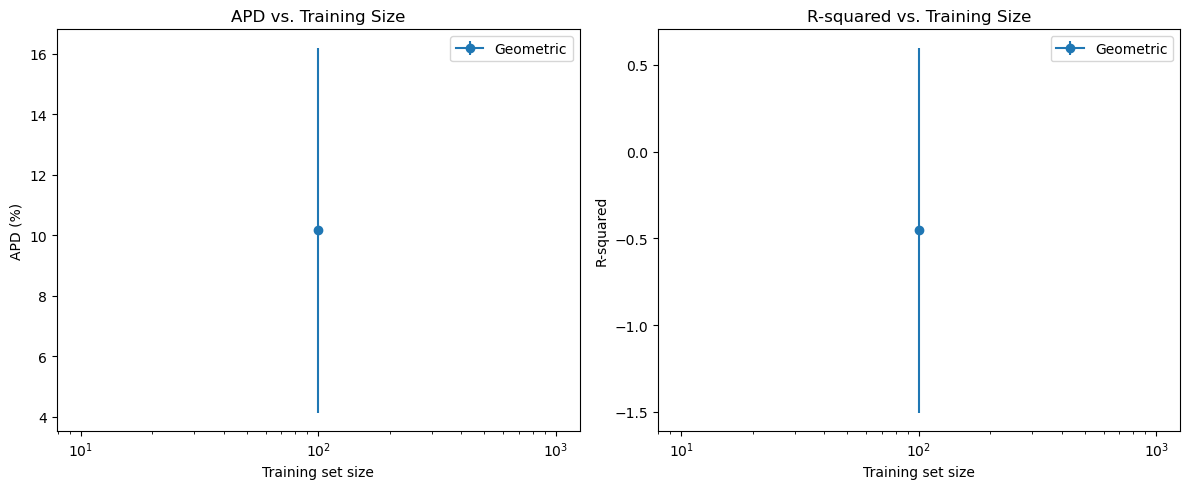

In [87]:
#plot learning curves

#APD
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for name, results in all_results.items():
    means = [np.mean(results[n]['APD']) for n in subset_sizes]
    stds  = [np.std (results[n]['APD']) for n in subset_sizes]
    plt.errorbar(subset_sizes, means, yerr=stds, marker='o', label=name)
plt.xscale('log'); plt.xlabel('Training set size'); plt.ylabel('APD (%)')
plt.title('APD vs. Training Size'); plt.legend()

#R-squared
plt.subplot(1,2,2)
for name, results in all_results.items():
    means = [np.mean(results[n]['R2']) for n in subset_sizes]
    stds  = [np.std (results[n]['R2']) for n in subset_sizes]
    plt.errorbar(subset_sizes, means, yerr=stds, marker='o', label=name)
plt.xscale('log'); plt.xlabel('Training set size'); plt.ylabel('R-squared')
plt.title('R-squared vs. Training Size'); plt.legend()

plt.tight_layout()
plt.show()

## Task 3

In [ ]:
from rdkit import Chem  
from tqdm import tqdm
import re
from typing import List

In [ ]:
def is_valid_smiles(smiles):
    if smiles is None:
        return False
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

def canonicalize(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return Chem.MolToSmiles(mol, canonical=True)
        return 'None'
    except:
        return 'None'

In [ ]:
canonicalize("COO"), canonicalize("O(C)O")

('COO', 'COO')

In [ ]:
is_valid_smiles("COO"), is_valid_smiles("O(C)O"), is_valid_smiles("C##")

(True, True, False)

In [ ]:
# prepare the data, use the same tokenizer as in task 1 for SMILES
tokenizer = SMILESAISTokenizer()
tokenizer.build_vocabulary(train_data)
vocab_size = len(tokenizer.vocab)
max_len = 100  #we need this length to know how much padding to add

def smiles_to_tensor(smiles):
    """
    converts SMILES string into PyTorch tensor of token indices, the tensor 
    representation is needed for the loss function and such. 
    """ 
    return torch.tensor(tokenizer.encode(smiles, max_length=max_len), dtype=torch.long)

train_tensors = torch.stack([smiles_to_tensor(s) for s in train_data])
val_tensors = torch.stack([smiles_to_tensor(s) for s in val_data])


In [ ]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden_dim=256):
        super().__init__()
        #embedding for each token (character) present in the vocab
        self.emb = nn.Embedding(vocab_size, emb_dim) 
        #LSTM layer   
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        # Fully connected layer: maps LSTM output to character. 
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.emb(x)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)
        return out, hidden

In [ ]:

def train_epoch(model, optimizer, criterion, data, batch_size=64):
    """
    trains model for one epoch, returns avg loss for this epoch. 
    """
    model.train() #put model into training mode
    total_loss = 0

    for i in range(0, len(data), batch_size): #create mini batches
        batch = data[i:i+batch_size]
        input = batch[:, :-1].to(device) #input is but the last token
        target = batch[:, 1:].to(device) #target is the last token

        optimizer.zero_grad()
        out, _ = model(input) #out of size [batch_size, sequence_length, vocab_size]
        loss = criterion(out.view(-1, out.size(-1)), target.view(-1))
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * input.size(0)
    return total_loss / len(data)

def validate(model, criterion, data, batch_size=64):
    """
    validates model for one epoch, returns avg loss for this epoch. 
    works the same as the train_epoch but on validation data
    """
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for i in range(0, len(data), batch_size):
            batch = data[i:i+batch_size]
            inp = batch[:, :-1].to(device)
            target = batch[:, 1:].to(device)

            out, _ = model(inp)
            loss = criterion(out.view(-1, out.size(-1)), target.view(-1))
            total_loss += loss.item() * inp.size(0)
    return total_loss / len(data)

#initiate model, optimizer and criterion (loss function)
model = CharLSTM(vocab_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.token_to_idx['<PAD>'])

NameError: name 'device' is not defined

In [ ]:
#TRAININGS LOOP

best_val_loss = float('inf')
patience = 3
patience_counter = 0
best_model_state = None

for epoch in range(50):
    train_loss = train_epoch(model, optimizer, criterion, train_tensors)
    val_loss = validate(model, criterion, val_tensors)  # assuming val_tensors exists

    print(f"Epoch {epoch+1}: Train loss = {train_loss:.4f}, Val loss = {val_loss:.4f}")

    if val_loss < best_val_loss: #save the state_dict of the best model
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

# reload the model with the best weights
model.load_state_dict(best_model_state)


In [ ]:
def sample_smiles(model, tokenizer, max_len=100):
    """
    Generates a SMILES string using the trained model.
    returns a SMILES string generated by the model
    """
    model.eval()
    with torch.no_grad():
        #start with the <SOS> token
        inp = torch.tensor([[tokenizer.token_to_idx['<SOS>']]], device=device)
        hidden = None
        tokens = []

        for _ in range(max_len):
            out, hidden = model(inp, hidden)

            # Get the predicted token probabilities, apply temperature scaling
            probs = torch.softmax(out[0, -1], dim=0)
            #sample a token from the distribution
            idx = torch.multinomial(probs, 1).item()
            #id end of string or padding, then stop
            if tokenizer.idx_to_token.get(idx) == '<EOS>' or tokenizer.idx_to_token.get(idx) == '<PAD>':
                break
            tokens.append(idx)
            # Prepare the next input token
            inp = torch.tensor([[idx]], device=device)
        return tokenizer.decode(tokens)

In [ ]:
#generate SMILES strings of new molecules
generated = [sample_smiles(model, tokenizer, max_len=max_len) for _ in range(5000)]
generated = [s for s in generated if s]

# Check and report the validity, uniqueness, and novelty of the generated samples
valid = [s for s in generated if is_valid_smiles(s)]
canonical_valid = [canonicalize(s) for s in valid if canonicalize(s) != 'None']
canonical_train = set(canonicalize(s) for s in train_data)
unique = set(canonical_valid)
novel = [s for s in unique if s not in canonical_train]

print(f"Validity: {len(valid)/len(generated):.3f}")
print(f"Uniqueness: {len(unique)/len(valid):.3f}")
print(f"Novelty: {len(novel)/len(valid):.3f}")